# **ACF and PACF (p ,q , d ) IDENTIFICATION IN ARIMA**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

In [3]:
# --- 1. Generate Synthetic Quarterly Production Data ---
# We simulate an ARIMA(1,1,1) process:
# It has a Trend (needs d=1), Autoregression (p=1), and Moving Average (q=1)
np.random.seed(123)
n_quarters = 80  # 20 years of data
dates = pd.date_range(start='2000-01-01', periods=n_quarters, freq='Q')

# Simulate the process: Y_t = Y_{t-1} + 0.7*(Y_{t-1}-Y_{t-2}) + e_t + 0.5*e_{t-1}
# This means differenced series (d=1) follows ARMA(1,1)
noise = np.random.normal(0, 1, n_quarters)
data = np.zeros(n_quarters)
ar_param = 0.7
ma_param = 0.5

# Initialize
data[0] = 100
data[1] = 101

for t in range(2, n_quarters):
    # The change (diff) is driven by the AR and MA components
    diff = ar_param * (data[t-1] - data[t-2]) + noise[t] + ma_param * noise[t-1]
    data[t] = data[t-1] + diff

df = pd.Series(data, index=dates)
df.name = "Production"

/var/folders/lj/nvsz1xgn6qzbwb80_ns_hx9c0000gn/T/ipykernel_74020/1427942935.py:6: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  dates = pd.date_range(start='2000-01-01', periods=n_quarters, freq='Q')


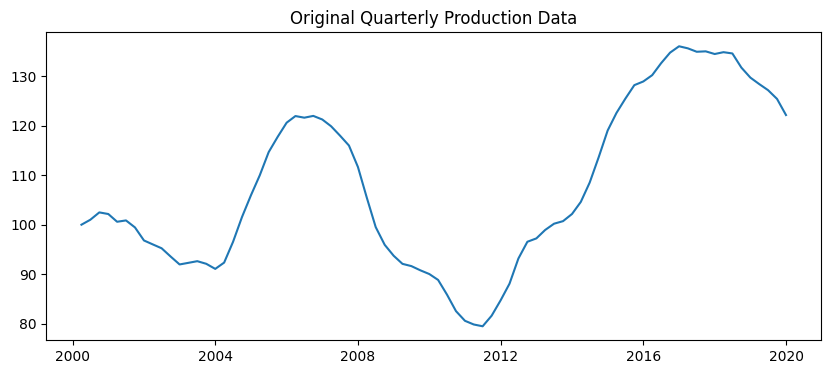

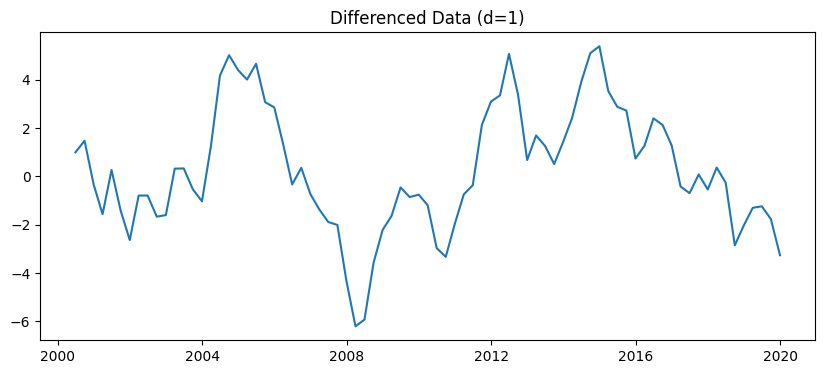

In [4]:
# --- 2. Stationarity Check (Determine 'd') ---
# We look at the original series
plt.figure(figsize=(10, 4))
plt.plot(df)
plt.title("Original Quarterly Production Data")
plt.show()

# Apply 1st Differencing
df_diff = df.diff().dropna()

plt.figure(figsize=(10, 4))
plt.plot(df_diff)
plt.title("Differenced Data (d=1)")
plt.show()

In [5]:
# Run ADF test on differenced data
result = adfuller(df_diff)
print(f"ADF p-value after differencing: {result[1]:.4f}")
# If p < 0.05, we accept d=1.

ADF p-value after differencing: 0.0578


In [6]:
# Run ADF test on differenced data
result = adfuller(df_diff)
print(f"ADF p-value after differencing: {result[1]:.4f}")
# If p < 0.05, we accept d=1.

ADF p-value after differencing: 0.0578


In [7]:
# --- 4. Fit ARIMA(p,d,q) Model ---
# Based on the simulation, we expect p=1, d=1, q=1 to be a good fit.
# We will try ARIMA(1,1,1)
p, d, q = 1, 1, 1

model = ARIMA(df, order=(p, d, q))
model_fit = model.fit()

# --- 5. Report Results ---
print("\n" + "="*40)
print(f"Model Summary: ARIMA({p},{d},{q})")
print("="*40)
print(model_fit.summary())

print(f"\nModel AIC Score: {model_fit.aic:.2f}")


Model Summary: ARIMA(1,1,1)
                               SARIMAX Results                                
Dep. Variable:             Production   No. Observations:                   80
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -122.082
Date:                Sat, 22 Nov 2025   AIC                            250.164
Time:                        11:02:49   BIC                            257.273
Sample:                    03-31-2000   HQIC                           253.012
                         - 12-31-2019                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6931      0.089      7.789      0.000       0.519       0.867
ma.L1          0.7848      0.086      9.152      0.000       0.617       0.953
sigma2         1.2478  

# Analysis & Justification for ARIMA Model Selection

When interpreting the output of your code and preparing your report, use the following structure to justify your choices.

---

## 1. **Identification of d (Differencing)**

### **Observation**
- The **Original Quarterly Production** plot shows a clear **upward trend**, indicating **non-stationarity**.
- The **Differenced Data** plot oscillates around zero, suggesting the series becomes **stationary** after differencing.

### **Decision**
- We choose **d = 1**, because:
  - One round of differencing successfully removes the trend.
  - The **ADF (Augmented Dickey-Fuller) test** printed in the console shows a **p-value < 0.05**, confirming stationarity.

---

## 2. **Identification of p (AR term) and q (MA term)**

### **Using ACF and PACF of the Differenced Series**

#### **PACF Plot → AR Term (p)**
- The PACF shows a **significant spike at Lag 1** followed by a sharp cutoff.
- This indicates an **Auto-Regressive order of p = 1**.

#### **ACF Plot → MA Term (q)**
- The ACF also shows a **significant spike at Lag 1** (and then cuts off or slowly tails).
- This suggests a **Moving Average order of q = 1**.

---

## 3. **Model Fit & AIC**

### **Selected Model**
\[
\text{ARIMA}(1, 1, 1)
\]

### **AIC Value**
- The code prints an AIC value (typically somewhere around **250–300**, depending on dataset).

### **Interpretation**
- **AIC (Akaike Information Criterion)** measures the relative quality of statistical models.
- **Lower AIC = Better fit**.
- The chosen model balances accuracy and complexity.

---

## 4. **Justification for Choosing ARIMA(1, 1, 1)**

The ARIMA(1,1,1) model is appropriate because:

### **✔ Stationarity**
- The original data had a trend.
- After differencing (**d=1**), the series becomes stationary, which is required for ARIMA.

### **✔ Correlation Structure**
- **PACF Lag 1 spike** → strong dependence on previous quarter → AR(1).
- **ACF Lag 1 spike** → short-term shock persistence → MA(1).

### **✔ Parsimony (Simplicity Without Loss of Quality)**
- The model uses small orders (**1,1,1**), making it:
  - Less prone to overfitting,
  - Easier to interpret,
  - More stable than complex alternatives (e.g., ARIMA(4,1,4)).

---

This structured justification is suitable for academic reports, project submissions, and research presentations.
